# Setup & Libraries

In [1]:
!pip install thop umap-learn

import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from thop import profile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dir = '/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/train'
test_dir = '/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/test'

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=base_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

2026-04-04 11:32:54.555631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775302374.711339      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775302374.755900      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775302375.121968      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775302375.122001      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775302375.122003      55 computation_placer.cc:177] computation placer alr

MAE Architecture & Loss

In [2]:
class MAE_DenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = models.densenet121(weights=None)
        self.feature_dim = self.encoder.classifier.in_features
        self.encoder.classifier = nn.Identity()
        
        self.decoder = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3 * 224 * 224),
            nn.Sigmoid()
        )

    def forward(self, x, mask_ratio=0.75):
        batch, c, h, w = x.shape
        mask = torch.rand(batch, 1, h, w).to(device) > mask_ratio
        x_masked = x * mask
        
        latent = self.encoder(x_masked)
        reconstructed = self.decoder(latent)
        reconstructed = reconstructed.view(batch, c, h, w)
        
        return reconstructed, x, mask

def mae_loss(reconstructed, original, mask):
    loss = F.mse_loss(reconstructed, original, reduction='none')
    loss = (loss * (1 - mask.float())).mean()
    return loss

# MAE Pretraining

Epoch [1/10], Loss: 0.0124
Epoch [2/10], Loss: 0.0076
Epoch [3/10], Loss: 0.0068
Epoch [4/10], Loss: 0.0063
Epoch [5/10], Loss: 0.0059
Epoch [6/10], Loss: 0.0054
Epoch [7/10], Loss: 0.0051
Epoch [8/10], Loss: 0.0048
Epoch [9/10], Loss: 0.0045
Epoch [10/10], Loss: 0.0042

Pretraining Time: 434.03 seconds


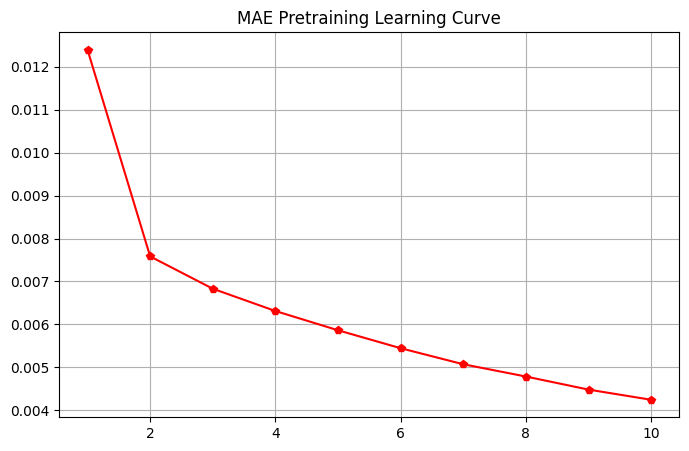

In [3]:
model = MAE_DenseNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0003)
scaler = torch.amp.GradScaler('cuda')

epochs = 10
pretrain_losses = []
start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, _ in train_loader:
        torch.cuda.empty_cache()
        images = images.to(device)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            recon, target, mask = model(images)
            loss = mae_loss(recon, target, mask)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print(f"\nPretraining Time: {time.time() - start_time:.2f} seconds")
torch.save(model.encoder.state_dict(), 'mae_frozen_encoder.pth')

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), pretrain_losses, marker='p', color='red')
plt.title('MAE Pretraining Learning Curve')
plt.grid(True)
plt.show()

# MAE Feature Analysis

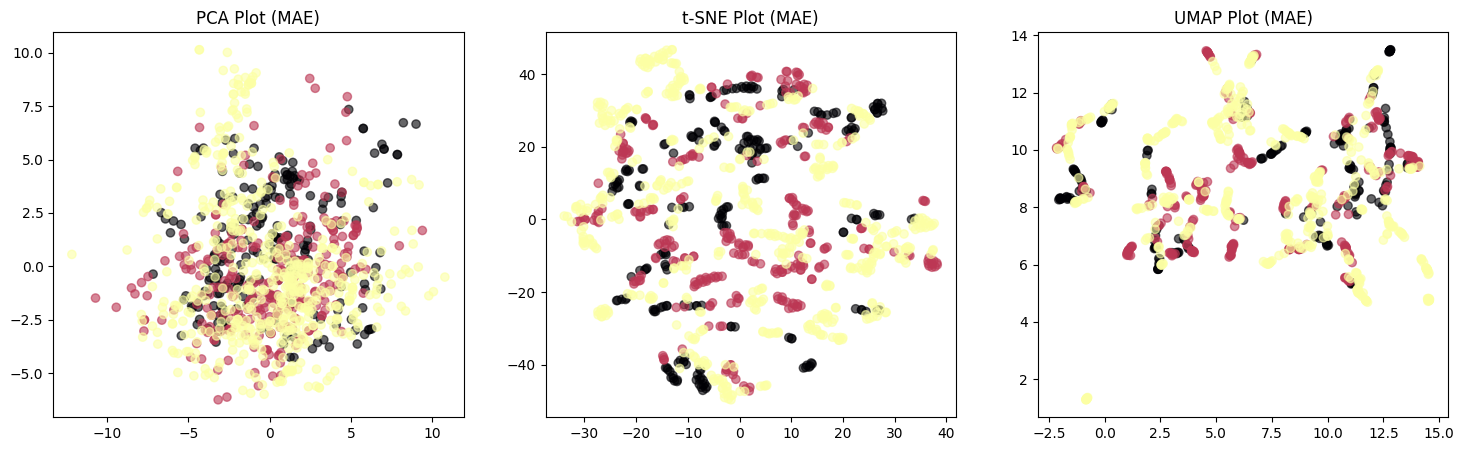

Silhouette Score (t-SNE): -0.0289


In [4]:
def extract_features_mae(model, dataloader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            h = model.encoder(imgs)
            features.append(h.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(labels)

X_train, y_train = extract_features_mae(model, train_loader)
X_test, y_test = extract_features_mae(model, test_loader)

pca_res = PCA(n_components=2).fit_transform(X_test)
tsne_res = TSNE(n_components=2, perplexity=30).fit_transform(X_test)
umap_res = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X_test)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1); plt.scatter(pca_res[:, 0], pca_res[:, 1], c=y_test, cmap='inferno', alpha=0.6); plt.title('PCA Plot (MAE)')
plt.subplot(1, 3, 2); plt.scatter(tsne_res[:, 0], tsne_res[:, 1], c=y_test, cmap='inferno', alpha=0.6); plt.title('t-SNE Plot (MAE)')
plt.subplot(1, 3, 3); plt.scatter(umap_res[:, 0], umap_res[:, 1], c=y_test, cmap='inferno', alpha=0.6); plt.title('UMAP Plot (MAE)')
plt.show()

print(f"Silhouette Score (t-SNE): {silhouette_score(tsne_res, y_test):.4f}")

# MAE Evaluation & Fine-Tuning)

In [5]:
start_train = time.time()
lp_model = MLPClassifier(hidden_layer_sizes=(), max_iter=1000).fit(X_train, y_train)
print(f"Linear Probe Train Time: {time.time() - start_train:.4f} sec")

y_pred_lp = lp_model.predict(X_test)
y_prob_lp = lp_model.predict_proba(X_test)

for name, clf in {"Linear Probe": lp_model, "SVM": SVC(probability=True).fit(X_train, y_train), "Random Forest": RandomForestClassifier().fit(X_train, y_train)}.items():
    print(f"{name} -> Accuracy: {clf.score(X_test, y_test):.4f}")

class FineTuneModel_MAE(nn.Module):
    def __init__(self, base_encoder, num_classes):
        super().__init__()
        self.encoder = base_encoder
        self.classifier = nn.Linear(1024, num_classes)
    def forward(self, x):
        h = self.encoder(x)
        return self.classifier(h)

ft_model = FineTuneModel_MAE(copy.deepcopy(model.encoder), len(train_dataset.classes)).to(device)
optimizer_ft = optim.Adam(ft_model.parameters(), lr=1e-5)
criterion_ft = nn.CrossEntropyLoss()

for epoch in range(5):
    ft_model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        loss = criterion_ft(ft_model(imgs), lbls)
        optimizer_ft.zero_grad(); loss.backward(); optimizer_ft.step()
    print(f"Fine-tuning Epoch {epoch+1}/5 complete.")

ft_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        _, predicted = torch.max(ft_model(imgs).data, 1)
        total += lbls.size(0); correct += (predicted == lbls).sum().item()
print(f"Full Fine-tuning Accuracy: {100 * correct / total:.2f}%")

Linear Probe Train Time: 5.9774 sec
Linear Probe -> Accuracy: 0.8012
SVM -> Accuracy: 0.7342
Random Forest -> Accuracy: 0.9952
Fine-tuning Epoch 1/5 complete.
Fine-tuning Epoch 2/5 complete.
Fine-tuning Epoch 3/5 complete.
Fine-tuning Epoch 4/5 complete.
Fine-tuning Epoch 5/5 complete.
Full Fine-tuning Accuracy: 97.77%


# MAE Final Metrics & GFLOPs

k-NN (k=1) Accuracy: 0.9990
k-NN (k=5) Accuracy: 0.9903
k-NN (k=20) Accuracy: 0.9263

Classification Report:
              precision    recall  f1-score   support

          AD       0.83      0.67      0.74       225
          CN       0.84      0.73      0.78       288
         MCI       0.78      0.90      0.83       518

    accuracy                           0.80      1031
   macro avg       0.82      0.76      0.78      1031
weighted avg       0.81      0.80      0.80      1031



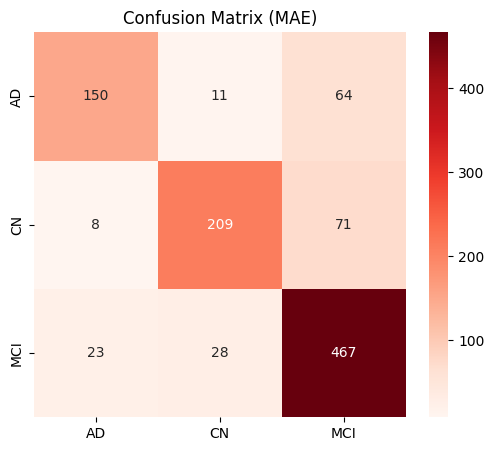

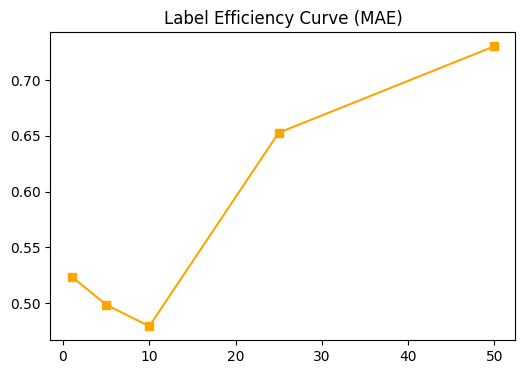

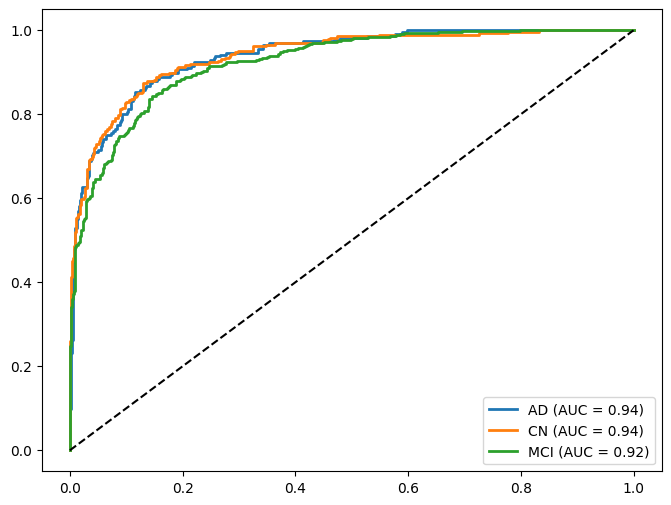


GFLOPs: 2.8960


In [7]:
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    print(f"k-NN (k={k}) Accuracy: {knn.score(X_test, y_test):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lp, target_names=train_dataset.classes))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lp), annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap="Reds")
plt.title("Confusion Matrix (MAE)")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot([1, 5, 10, 25, 50], [MLPClassifier(hidden_layer_sizes=(), max_iter=2000).fit(X_train[:max(1, int(len(X_train)*p/100))], y_train[:max(1, int(len(X_train)*p/100))]).score(X_test, y_test) for p in [1, 5, 10, 25, 50]], marker='s', color='orange')
plt.title("Label Efficiency Curve (MAE)")
plt.show()

classes_list = list(range(len(train_dataset.classes)))
y_test_bin = label_binarize(y_test, classes=classes_list)
plt.figure(figsize=(8, 6))
for i in range(len(train_dataset.classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lp[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{train_dataset.classes[i]} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--'); plt.legend(); plt.show()

input_dummy = torch.randn(1, 3, 224, 224).to(device)
macs, params = profile(model.encoder, inputs=(input_dummy,), verbose=False)
print(f"\nGFLOPs: {macs / 1e9:.4f}")